# Logistic Regression

We fit the model $P(Y=1 \mid X=x) = \dfrac{1}{1+e^{-(a + bx)}}$ to the data of the exercise sheet:

| Hours studied ($X$) | Pass ($Y$) |
|---|---|
| 0 | 0 |
| 4 | 0 |
| 3 | 1 |
| 8 | 1 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## The data and the cost function

The cost is the total log loss over the four data points.

In [2]:
X = np.array([0, 4, 3, 8])
Y = np.array([0, 0, 1, 1])


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def loss(a, b):
    p = sigmoid(a + b * X)
    return -np.sum(Y * np.log(p) + (1 - Y) * np.log(1 - p))


loss(0, 0)  # with a = b = 0, every p is 1/2, so the cost is 4*log(2)


np.float64(2.772588722239781)

## Method 1: grid search

Careful with two things here:
- the running best value must be updated as well (not only `best_a` and `best_b`);
- the grid must be wide enough to contain the optimum. Try `a` in `[-1, 1]` only, and you will
  miss it entirely: the best `a` is around `-2.3`.

In [ ]:
best_a = 0
best_b = 0
best = loss(best_a, best_b)

N = 201
for a in np.linspace(-5, 5, N):
    for b in np.linspace(-2, 2, N):
        if best > loss(a, b):
            best = loss(a, b)
            best_a = a
            best_b = b

print(f"a = {best_a:.4f} ; b = {best_b:.4f} ; cost = {best:.4f}")


a = -2.3000 ; b = 0.6400 ; cost = 1.8861


## Method 2: gradient descent

Grid search only gives us the resolution of the grid.
We refine it with gradient descent, which is what we would use in practice.

The gradient of the log loss has a very simple form:
$$\frac{\partial \mathcal{L}}{\partial a} = \sum_k (p_k - y_k)
\qquad \qquad
\frac{\partial \mathcal{L}}{\partial b} = \sum_k x_k (p_k - y_k)$$

In [4]:
def gradient(a, b):
    p = sigmoid(a + b * X)
    return np.sum(p - Y), np.sum(X * (p - Y))


a, b = best_a, best_b   # start from the grid search result
eta = 0.05              # learning rate

for step in range(20001):
    grad_a, grad_b = gradient(a, b)
    a -= eta * grad_a
    b -= eta * grad_b
    if step % 5000 == 0:
        print(f"step {step:>5} : a = {a:>8.4f} ; b = {b:.4f} ; cost = {loss(a, b):.6f}")

best_a, best_b = a, b
print(f"\nfinal: a = {best_a:.4f} ; b = {best_b:.4f} ; cost = {loss(best_a, best_b):.4f}")


step     0 : a =  -2.3003 ; b = 0.6387 ; cost = 1.886077
step  5000 : a =  -2.2973 ; b = 0.6366 ; cost = 1.886067
step 10000 : a =  -2.2973 ; b = 0.6366 ; cost = 1.886067
step 15000 : a =  -2.2973 ; b = 0.6366 ; cost = 1.886067
step 20000 : a =  -2.2973 ; b = 0.6366 ; cost = 1.886067

final: a = -2.2973 ; b = 0.6366 ; cost = 1.8861


**Check:** at the minimum the gradient is zero, which means $\sum_k p_k = \sum_k y_k$ and
$\sum_k x_k p_k = \sum_k x_k y_k$.

In [5]:
p = sigmoid(best_a + best_b * X)
print(f"sum of p   = {np.sum(p):.4f}   (should be {np.sum(Y)})")
print(f"sum of x*p = {np.sum(X * p):.4f}   (should be {np.sum(X * Y)})")


sum of p   = 2.0000   (should be 2)
sum of x*p = 11.0000   (should be 11)


## Predictions

In [6]:
def classifier(x, a=None, b=None):
    a = best_a if a is None else a
    b = best_b if b is None else b
    return sigmoid(a + b * x)


for hours in (0, 1, 10):
    print(f"P(pass | {hours:>2} hours studied) = {classifier(hours):.3f}")


P(pass |  0 hours studied) = 0.091
P(pass |  1 hours studied) = 0.160
P(pass | 10 hours studied) = 0.983


The model is 50% confident when $a + bx = 0$, i.e. after $-a/b$ hours of study:
that is the decision boundary.

In [7]:
boundary = -best_a / best_b
print(f"decision boundary: {boundary:.2f} hours")


decision boundary: 3.61 hours


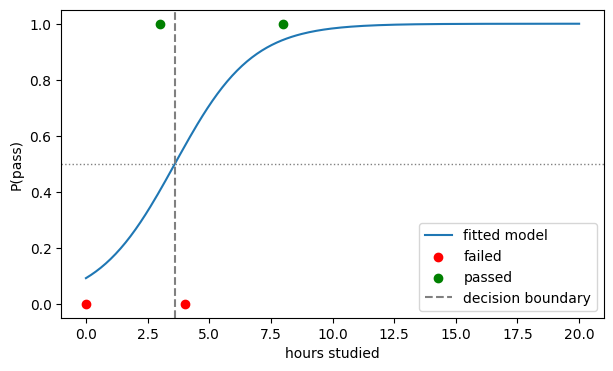

In [8]:
xs = np.linspace(0, 20, 200)
ys = classifier(xs)

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="fitted model")
plt.scatter(X[Y == 0], Y[Y == 0], color="red", zorder=3, label="failed")
plt.scatter(X[Y == 1], Y[Y == 1], color="green", zorder=3, label="passed")
plt.axvline(boundary, color="gray", linestyle="--", label="decision boundary")
plt.axhline(0.5, color="gray", linestyle=":", linewidth=1)
plt.xlabel("hours studied")
plt.ylabel("P(pass)")
plt.legend()
plt.show()


Note that the two classes overlap (the student who studied 4 hours failed, while the one who
studied 3 hours passed), so no model of this shape can classify the four points perfectly:
the cost cannot reach 0.